A driver for a simple RBF-PU method

In [53]:
import numpy as np
from rbf.pde.nodes import poisson_disc_nodes
from PuHelper import *
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#Params
epsilon = 2
delta = 0.05
nodes_in_patch= 50
overlap = 3

In [55]:
vert = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
edges = np.array([[0, 1], [1, 2], [2, 3], [3, 0]])
nodes, groups, _ = poisson_disc_nodes(delta, (vert, edges))

In [56]:

centers = GenCenters(nodes, nodes_in_patch, overlap)
print(f"Generated {len(centers)} centers.")
print(f"We have {len(nodes)} nodes and {len(centers)} centers, with {nodes_in_patch} nodes per patch and an overlap of {overlap}.")

Generated 19 centers.
We have 326 nodes and 19 centers, with 50 nodes per patch and an overlap of 3.


In [57]:
patches, radii, node_to_patch = GenPatches(nodes, centers, nodes_in_patch)

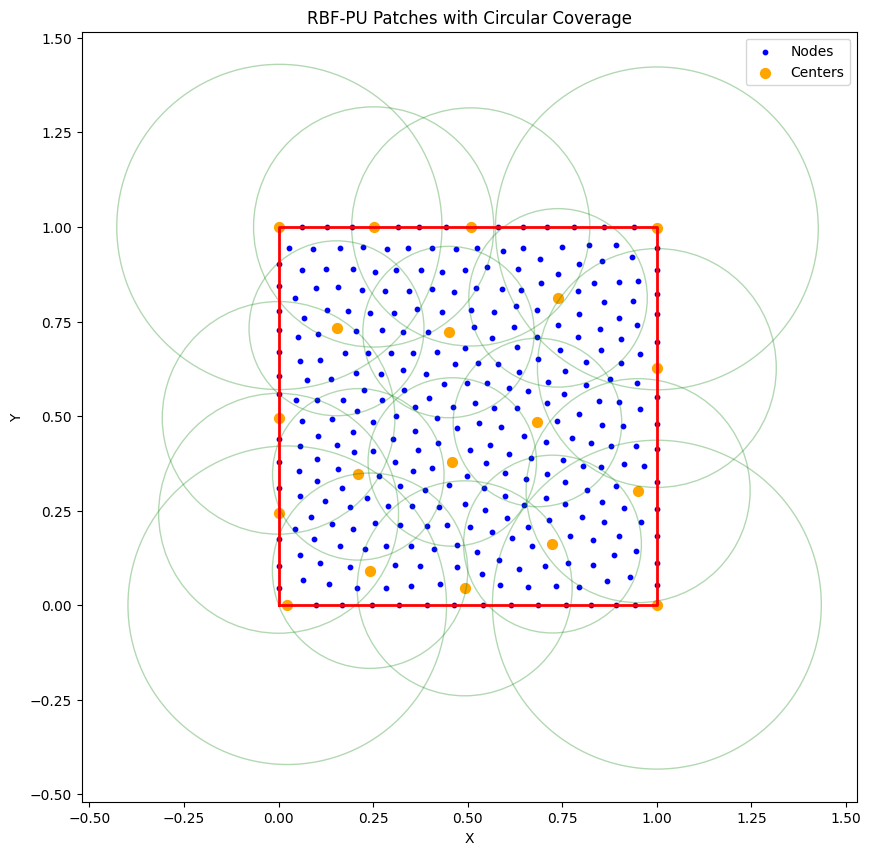

Max patch radius: 0.4347
Min patch radius: 0.2226
Mean patch radius: 0.3013


In [58]:
# Plot the circular patches
plt.figure(figsize=(10, 10))
plt.scatter(nodes[:, 0], nodes[:, 1], s=10, c='blue', label='Nodes')
plt.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1], s=50, c='orange', label='Centers')

# Draw circles for each patch
for center, radius in zip(centers, radii):
    circle = plt.Circle(center, radius, fill=False, edgecolor='green', alpha=0.3)
    plt.gca().add_patch(circle)

plt.plot(vert[[0, 1, 2, 3, 0], 0], vert[[0, 1, 2, 3, 0], 1], 'r-', linewidth=2)
plt.axis('equal')
plt.title('RBF-PU Patches with Circular Coverage')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

print(f"Max patch radius: {np.max(radii):.4f}")
print(f"Min patch radius: {np.min(radii):.4f}")
print(f"Mean patch radius: {np.mean(radii):.4f}")


## Interpolation

In [59]:
f = np.sin(np.pi * nodes[:, 0]) * np.sin(np.pi * nodes[:, 1])

In [ ]:
matrices = GenLocalPhi(nodes, patches, epsilon)
local_weights = GenLocalWeights(patches, matrices, f)


In [61]:
X, Y = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10))

Exact = np.sin(np.pi * X) * np.sin(np.pi * Y)
Interpolated = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        point = np.array([X[i, j], Y[i, j]])
        Interpolated[i, j] = Interpolate(point, nodes, patches, centers, radii, local_weights, epsilon)

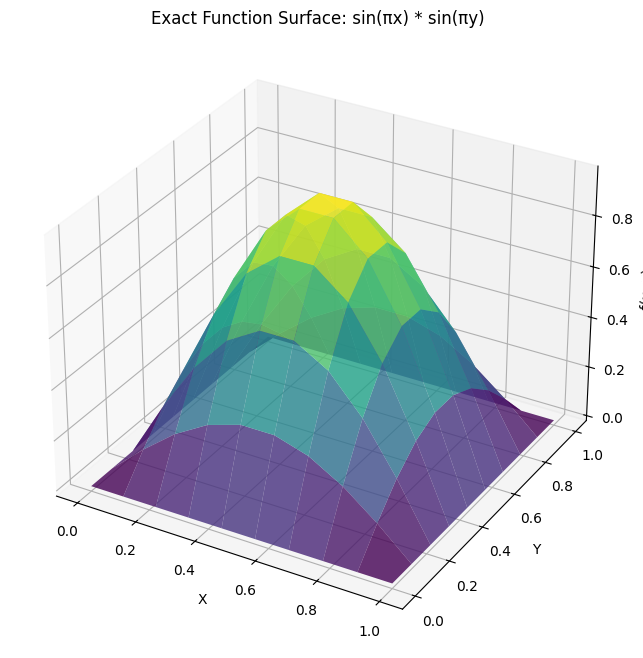

In [62]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Exact, cmap='viridis', alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Exact Function Surface: sin(πx) * sin(πy)')
plt.show()

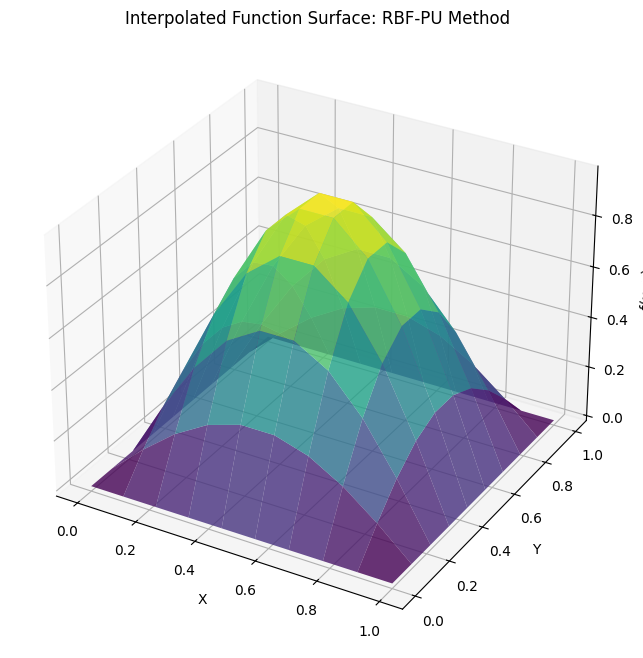

In [63]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Interpolated, cmap='viridis', alpha=0.8)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('f(x, y)')
ax.set_title('Interpolated Function Surface: RBF-PU Method')
plt.show()

In [64]:
error = np.max(np.abs(Exact - Interpolated))
print(f"Infinity norm error: {error:.6e}")

Infinity norm error: 1.571467e-06


In [65]:
condition_numbers = [np.linalg.cond(matrix) for matrix in matrices]
max_condition_number = np.max(condition_numbers)
print(f"Max local matrix condition number: {max_condition_number:.6e}")

Max local matrix condition number: 3.576049e+16
